# Week 38, Monday lecture: gradient descent revisited, automatic differentiation, adaptive learning rates and stochastic gradient descent

**FYS-STK3155/4155, Monday September 14, 2026**

This notebook accompanies Monday's lecture (`week38slides.pdf`). It contains,
in the order of the lecture, the code behind every figure shown:

1. **Following the steps** of gradient descent with and without momentum on a
   low-order polynomial (Sections 4.3, 4.5 and 4.6 of the book) — change the
   learning rate, the momentum parameter and the starting point and watch what
   happens.
2. **Automatic differentiation** (Section 4.14): a `Dual` class for forward
   mode, `jax.grad` on last week's least-squares problems, Hessians and one
   Newton step, and the Rosenbrock function optimised with nothing derived by
   hand.
3. **AdaGrad, RMSProp and Adam** (Sections 4.8–4.12): one step function for
   five optimisers, what "adaptive" looks like on a quadratic bowl, what
   happens when the bowl is rotated, and last week's unsolved Runge problem at
   degree 10.
4. **Stochastic gradient descent** (Section 4.7): minibatches, the noise in the
   minibatch gradient, constant learning rates against the schedule of
   Eq. (4.40).

The Tuesday session (`week38tuesday.ipynb`) builds on Parts 3 and 4, and the
weekly exercises (`exercisesweek38.ipynb`) ask you to write the code yourself.
Seed 2026 throughout, so that you reproduce exactly the numbers on the slides.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
GREEN = "#228833"
np.set_printoptions(precision=4, suppress=True)

## Part 1: following the steps, with and without momentum

Gradient descent, Eq. (4.10), moves against the gradient with a fixed learning
rate $\gamma$; momentum, Eq. (4.28), keeps a velocity that remembers the
previous gradients:

$$
\boldsymbol{v}_{k+1} = \beta \boldsymbol{v}_k + \gamma \nabla C(\boldsymbol{\theta}_k),
\qquad
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1},
$$

and $\beta = 0$ gives plain gradient descent back. The function `descend`
below is all there is to it. We start with a one-dimensional polynomial with
two minima, $f(x) = x^4 - 3x^2 + x$: a global minimum at $x = -1.30$
($f = -3.51$), a local one at $x = 1.13$ ($f = -1.07$), separated by a hump at
$x = 0.17$. Note that the gradient is an *argument* of `descend`: Part 2 is
about where it comes from when nobody has derived it.

In [7]:
def quartic(x):
    """A low-order polynomial with two minima: f(x) = x^4 - 3x^2 + x."""
    return x**4 - 3.0 * x**2 + x


def quartic_grad(x):
    return 4.0 * x**3 - 6.0 * x + 1.0


def descend(grad, x0, gamma, beta=0.0, num_iters=100):
    """Gradient descent with momentum, Eq. (4.28); beta = 0 is plain gradient descent, Eq. (4.10).
    Works for a scalar x as well as for a vector theta.  Returns every iterate."""
    x, v = np.array(x0, dtype=float), np.zeros_like(np.array(x0, dtype=float))
    history = [x.copy()]
    for _ in range(num_iters):
        v = beta * v + gamma * grad(x)
        x = x - v
        history.append(x.copy())
    return np.array(history)


In [8]:
for beta in (0.0, 0.7):
    path = descend(quartic_grad, 2.0, gamma=0.05, beta=beta, num_iters=40)
    print(f"beta = {beta}: start at x0 = 2")
    for k, x in enumerate(path[:8]):
        print(f"  step {k}: x = {x:8.4f}   f(x) = {quartic(x):8.4f}   f'(x) = {quartic_grad(x):8.4f}")
    print(f"  ... after 40 steps: x = {path[-1]:.4f}, f(x) = {quartic(path[-1]):.4f}\n")

beta = 0.0: start at x0 = 2
  step 0: x =   2.0000   f(x) =   6.0000   f'(x) =  21.0000
  step 1: x =   0.9500   f(x) =  -0.9430   f'(x) =  -1.2705
  step 2: x =   1.0135   f(x) =  -1.0130   f'(x) =  -0.9166
  step 3: x =   1.0594   f(x) =  -1.0479   f'(x) =  -0.6007
  step 4: x =   1.0894   f(x) =  -1.0625   f'(x) =  -0.3649
  step 5: x =   1.1076   f(x) =  -1.0678   f'(x) =  -0.2101
  step 6: x =   1.1181   f(x) =  -1.0695   f'(x) =  -0.1170
  step 7: x =   1.1240   f(x) =  -1.0700   f'(x) =  -0.0639
  ... after 40 steps: x = 1.1309, f(x) = -1.0702

beta = 0.7: start at x0 = 2
  step 0: x =   2.0000   f(x) =   6.0000   f'(x) =  21.0000
  step 1: x =   0.9500   f(x) =  -0.9430   f'(x) =  -1.2705
  step 2: x =   0.2785   f(x) =   0.0518   f'(x) =  -0.5847
  step 3: x =  -0.1623   f(x) =  -0.2406   f'(x) =   1.9565
  step 4: x =  -0.5687   f(x) =  -1.4342   f'(x) =   3.6764
  step 5: x =  -1.0369   f(x) =  -3.1065   f'(x) =   2.7618
  step 6: x =  -1.5028   f(x) =  -3.1775   f'(x) =  -3

Plain gradient descent walks down into the *nearest* minimum and stays there.
With $\beta = 0.7$ the velocity built up on the steep slope carries the iterate
over the hump into the global minimum. This is not a property of momentum in
general — try $\beta = 0.9$ below: the "ball" is now so frictionless that it
overshoots the global minimum, climbs back over the hump and ends in the local
one. Try also a different starting point. For a non-convex function none of
this week's methods comes with a guarantee.

In [9]:
for beta, x0 in ((0.9, 2.0), (0.7, 0.5), (0.7, -0.5)):
    path = descend(quartic_grad, x0, gamma=0.05, beta=beta, num_iters=60)
    print(f"beta = {beta}, x0 = {x0}: path {np.round(path[:9], 2)} ... ends at x = {path[-1]:.3f}")

beta = 0.9, x0 = 2.0: path [ 2.    0.95  0.07 -0.75 -1.69 -2.12 -1.29 -0.55 -0.07] ... ends at x = 1.180
beta = 0.7, x0 = 0.5: path [0.5  0.57 0.71 0.9  1.1  1.26 1.3  1.23 1.12] ... ends at x = 1.131
beta = 0.7, x0 = -0.5: path [-0.5  -0.68 -0.99 -1.36 -1.58 -1.47 -1.25 -1.13 -1.15] ... ends at x = -1.301


The second example is the two-dimensional quadratic bowl
$C(\boldsymbol{\theta}) = \tfrac12(\theta_1^2 + 10\,\theta_2^2)$, whose Hessian
is $\mathrm{diag}(1, 10)$, so $\kappa = 10$ and $\gamma_{\max} = 2/\lambda_{\max} = 0.2$
(Theorem 4.1, Eq. 4.20). Three runs of 40 steps: a small learning rate, a
learning rate near the bound (which zigzags across the steep direction), and
momentum at the same learning rate.

In [10]:
def bowl_grad(theta, lam1=1.0, lam2=10.0):
    """Gradient of the quadratic bowl C(theta) = (lam1 theta_1^2 + lam2 theta_2^2)/2, Hessian diag(lam1, lam2)."""
    return np.array([lam1, lam2]) * theta


In [11]:
theta0 = np.array([2.0, 1.4])
for gamma, beta in ((0.04, 0.0), (0.18, 0.0), (0.18, 0.3), (0.231, 0.27)):
    path = descend(bowl_grad, theta0, gamma, beta, num_iters=2000)
    dist = np.linalg.norm(path, axis=1)
    k = int(np.argmax(dist < 1e-6)) if (dist < 1e-6).any() else None
    print(f"gamma = {gamma:5.3f}, beta = {beta:4.2f}: first 4 steps {np.round(path[:4], 3).tolist()}, "
          f"iterations to 1e-6: {k}")

gamma = 0.040, beta = 0.00: first 4 steps [[2.0, 1.4], [1.92, 0.84], [1.843, 0.504], [1.769, 0.302]], iterations to 1e-6: 356
gamma = 0.180, beta = 0.00: first 4 steps [[2.0, 1.4], [1.64, -1.12], [1.345, 0.896], [1.103, -0.717]], iterations to 1e-6: 74
gamma = 0.180, beta = 0.30: first 4 steps [[2.0, 1.4], [1.64, -1.12], [1.237, 0.14], [0.893, 0.266]], iterations to 1e-6: 39
gamma = 0.231, beta = 0.27: first 4 steps [[2.0, 1.4], [1.538, -1.834], [1.058, 1.529], [0.684, -1.095]], iterations to 1e-6: 28


The last line uses the tuned pair $\gamma = 4/(\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}})^2 = 0.231$,
$\beta = ((\sqrt\kappa-1)/(\sqrt\kappa+1))^2 = 0.27$ of Eq. (4.31); the
iteration count then scales with $\sqrt\kappa$ instead of $\kappa$. The figure
shown in the lecture:

In [12]:
def fig_gd_steps(filename="week38_gd_steps.pdf"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    # (a) the quartic: plain descent stops in the nearer, shallower minimum; momentum rolls over the hump
    ax = axes[0]
    xs = np.linspace(-2.2, 2.2, 400)
    ax.plot(xs, quartic(xs), color=GREY, lw=1.5)
    for beta, col, lab in ((0.0, BLUE, r"plain, $\gamma=0.05$"), (0.7, RED, r"momentum, $\gamma=0.05$, $\beta=0.7$")):
        path = descend(quartic_grad, 2.0, gamma=0.05, beta=beta, num_iters=40)
        ax.plot(path, quartic(path), "o-", color=col, ms=3.5, lw=1, alpha=0.85, label=lab)
        ax.annotate("", xy=(path[1], quartic(path[1])), xytext=(path[0], quartic(path[0])),
                    arrowprops=dict(arrowstyle="->", color=col, lw=1.5))
    ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)=x^4-3x^2+x$")
    ax.set_title("(a) start at $x_0=2$: same learning rate, one extra line", fontsize=10)
    ax.set_ylim(-4.5, 8); ax.legend(fontsize=8, loc="upper center")
    # (b) the quadratic bowl with kappa = 10: too small, near the bound, and momentum
    ax = axes[1]
    t1, t2 = np.meshgrid(np.linspace(-1.2, 2.5, 200), np.linspace(-1.6, 1.6, 200))
    ax.contour(t1, t2, 0.5 * (t1**2 + 10.0 * t2**2), levels=np.geomspace(0.02, 20, 14), colors=GREY, linewidths=0.6)
    theta0 = np.array([2.0, 1.4])
    for gamma, beta, col, lab in ((0.04, 0.0, YELLOW, r"plain, $\gamma=0.04$"),
                                  (0.18, 0.0, BLUE, r"plain, $\gamma=0.18$ ($0.9\,\gamma_{\max}$)"),
                                  (0.18, 0.3, RED, r"momentum, $\gamma=0.18$, $\beta=0.3$")):
        path = descend(bowl_grad, theta0, gamma, beta, num_iters=40)
        ax.plot(path[:, 0], path[:, 1], "o-", color=col, ms=2.5, lw=1, label=lab)
    ax.plot(0, 0, "k*", ms=9)
    ax.set_xlabel(r"$\theta_1$ ($\lambda_1=1$)"); ax.set_ylabel(r"$\theta_2$ ($\lambda_2=10$)")
    ax.set_title(r"(b) $C=\frac{1}{2}(\theta_1^2+10\,\theta_2^2)$, $\kappa=10$, 40 steps each", fontsize=10)
    ax.legend(fontsize=8, loc="lower right"); ax.set_aspect("equal")
    fig.tight_layout(); fig.savefig(filename, bbox_inches="tight"); plt.close(fig)


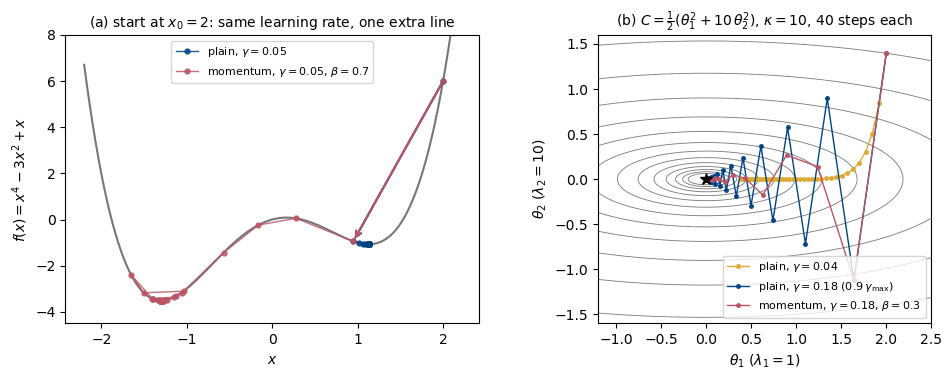

In [13]:
fig_gd_steps("week38_gd_steps.png")
Image("week38_gd_steps.png", width=900)

## Part 2: automatic differentiation (Section 4.14)

Every method today needs a gradient. For OLS we derived it by hand, Eq. (4.13);
for a network with a dozen layers that is possible but error-prone, and for a
model under development impractical. Automatic differentiation (AD) applies the
chain rule to the sequence of elementary operations a program executes, and
returns derivatives accurate to working precision at a cost a small constant
above the program itself. It is neither symbolic differentiation (which
manipulates formulas) nor numerical differentiation (finite differences,
Eqs. 4.57–4.60, at best $10^{-11}$ accurate and $2p$ evaluations per gradient).

### Forward mode in thirty lines: dual numbers

Introduce $\varepsilon$ with $\varepsilon^2 = 0$. Then
$g(a + b\varepsilon) = g(a) + g'(a)\,b\varepsilon$ exactly, Eq. (4.68), and the
product rule becomes the multiplication rule of dual numbers, Eq. (4.67).
Overload the operators and ordinary code computes its own derivative.

In [14]:
import math

class Dual:
    """A dual number a + b*eps with eps**2 = 0: a value and its derivative."""
    def __init__(self, val, dot=0.0):
        self.val, self.dot = val, dot
    def _lift(o):
        return o if isinstance(o, Dual) else Dual(o)
    def __add__(self, o):
        o = Dual._lift(o); return Dual(self.val + o.val, self.dot + o.dot)
    __radd__ = __add__
    def __sub__(self, o):
        o = Dual._lift(o); return Dual(self.val - o.val, self.dot - o.dot)
    def __mul__(self, o):               # the product rule, Eq. (4.67)
        o = Dual._lift(o)
        return Dual(self.val * o.val, self.val * o.dot + self.dot * o.val)
    __rmul__ = __mul__

def sin(d): return Dual(math.sin(d.val), math.cos(d.val) * d.dot)   # Eq. (4.68)
def log(d): return Dual(math.log(d.val), d.dot / d.val)

def f(x1, x2):                          # Eq. (4.61), ordinary code
    return log(x1) + x1 * x2 - sin(x2)

print("df/dx1 =", f(Dual(2.0, 1.0), Dual(5.0, 0.0)).dot, "  exact: 1/x1 + x2 =", 1 / 2.0 + 5.0)
print("df/dx2 =", f(Dual(2.0, 0.0), Dual(5.0, 1.0)).dot, "  exact: x1 - cos(x2) =", 2.0 - math.cos(5.0))

df/dx1 = 5.5   exact: 1/x1 + x2 = 5.5
df/dx2 = 1.7163378145367738   exact: x1 - cos(x2) = 1.7163378145367738


One sweep per input variable: forward mode costs $p$ sweeps for a gradient with
$p$ parameters. Reverse mode (adjoints, Eqs. 4.70–4.73, the tape) returns the
whole gradient in one backward sweep for two or three function evaluations,
whatever $p$ — the cheap gradient principle, Proposition 4.2 — and is what
backpropagation is. JAX implements both, together with a compiler.

### JAX: `grad`, `jit`, `vmap`

The first line matters: JAX uses single precision by default, and without it
every gradient check below agrees only to seven digits.

In [15]:
import jax
jax.config.update("jax_enable_x64", True)   # double precision throughout -- ALWAYS
import jax.numpy as jnp
from jax import grad, jit, vmap, hessian, jvp

def fscalar(x):
    return jnp.sin(2 * jnp.pi * x + x**2)

df = grad(fscalar)                 # reverse-mode gradient of a scalar function
print("f'(1)  =", df(1.0))         # 4.475424121402227, exact to all digits
print("f''(1) =", grad(grad(fscalar))(1.0))
xs = jnp.linspace(0.0, 1.0, 5)
print("f' at five points:", vmap(df)(xs))
fast_df = jit(df)                  # compiled on first call, then very fast
print("compiled:", fast_df(1.0))

f'(1)  = 4.475424121402227
f''(1) = -56.653694780342995
f' at five points: [ 6.2832 -0.4237 -7.0568  4.1508  4.4754]
compiled: 4.475424121402227


f' at five points: [ 6.2832 -0.4237 -7.0568  4.1508  4.4754]
compiled: 4.475424121402227


### The least-squares gradient without deriving it

Last week's exercise data, $f(x) = 2 - x + 5x^2$ on $[-2, 2]$ with $n = 100$,
noise $0.5$, degree-5 polynomial features, standardised columns and centred
$\boldsymbol{y}$. We write the cost of Eq. (4.12) as an ordinary function and
compare `jax.grad` of it with the hand-derived gradient of Eq. (4.13).

In [16]:
def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered


def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)


def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16): (1/n)||X theta - y||^2 + lambda theta^T theta."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta


def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta


def hessian_eigs(X, lam=0.0):
    """Eigenvalues of the Hessian (2/n) X^T X + 2 lambda I, Eqs. (4.14) and (4.17)."""
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))


In [17]:
X, y = exercise_data(degree=5)
n = len(y)
Xj, yj = jnp.asarray(X), jnp.asarray(y)

def cost_jax(theta, X, y, lam=0.0):                 # Eq. (4.12) / (4.16), ordinary code
    return jnp.sum((X @ theta - y)**2) / len(y) + lam * theta @ theta

cost_grad = jit(grad(cost_jax, argnums=0))          # d cost / d theta, compiled

rng = np.random.default_rng(2026)
theta = rng.normal(size=5)
for lam in (0.0, 0.01):
    g_ad = np.asarray(cost_grad(jnp.asarray(theta), Xj, yj, lam))
    g_hand = gradient(theta, X, y, lam)
    print(f"lambda = {lam}: max |AD - hand| = {np.max(np.abs(g_ad - g_hand)):.1e}")

# the derivative with respect to lambda, argument number 3: theta^T theta, by Eq. (4.16)
print("dC/dlambda =", grad(cost_jax, argnums=3)(jnp.asarray(theta), Xj, yj, 0.01), "=", theta @ theta)

lambda = 0.0: max |AD - hand| = 1.8e-15
lambda = 0.01: max |AD - hand| = 1.8e-15
dC/dlambda = 6.638570270283929 = 6.638570270283929


dC/dlambda = 6.638570270283929 = 6.638570270283929


Agreement to rounding — an error in the algebra would show up as $10^{-2}$, not
$10^{-15}$. What the check cannot tell you is whether the cost you wrote down is
the one you meant (a missing $1/n$, a penalised intercept). `grad` differentiates
with respect to *any* argument, so $\partial C/\partial\lambda$ comes for free.

### Hessians, one Newton step, Hessian–vector products

In [18]:
H = np.asarray(hessian(cost_jax)(jnp.asarray(theta), Xj, yj, 0.0))      # forward-over-reverse
print("max |H_AD - (2/n) X^T X| =", np.max(np.abs(H - (2.0 / n) * X.T @ X)))   # Eq. (4.14), to rounding

theta0 = jnp.asarray(rng.normal(size=5))                                    # one Newton step, Eq. (4.8)
theta_newton = theta0 - jnp.linalg.solve(H, grad(cost_jax)(theta0, Xj, yj, 0.0))
print("one Newton step:", np.asarray(theta_newton))
print("closed form:    ", closed_form(X, y))

def hvp(f, theta, v):                                                       # Eq. (4.75): H v without forming H
    return jvp(grad(f), (theta,), (v,))[1]

v = jnp.ones(5)
print("H v by jvp(grad):", np.asarray(hvp(lambda th: cost_jax(th, Xj, yj), theta0, v)))
print("H v directly:    ", H @ np.ones(5))

max |H_AD - (2/n) X^T X| = 2.220446049250313e-16
one Newton step: [-1.2107  5.9442  0.1031 -0.0912  0.0479]
closed form:     [-1.2107  5.9442  0.1031 -0.0912  0.0479]
H v by jvp(grad): [5.829  4.4907 6.0875 4.2311 5.6822]
H v directly:     [5.829  4.4907 6.0875 4.2311 5.6822]


one Newton step: [-1.2107  5.9442  0.1031 -0.0912  0.0479]
closed form:     [-1.2107  5.9442  0.1031 -0.0912  0.0479]


H v by jvp(grad): [5.829  4.4907 6.0875 4.2311 5.6822]
H v directly:     [5.829  4.4907 6.0875 4.2311 5.6822]


### A function nobody differentiated: Rosenbrock (book Section 4.14.8)

$f(x,y) = (1-x)^2 + 100(y-x^2)^2$, Eq. (4.76), minimum at $(1,1)$ at the bottom
of a curved valley, $\kappa \approx 2500$ at the minimum, not convex. With the
gradient and the Hessian from JAX, the optimisers of Part 3 (defined below, so
run Part 3's first code cell before this one if you jump around) and Newton's
method are a few lines each. The `optimiser_step` function is introduced in
Part 3; we define it here already since the Rosenbrock comparison uses it.

In [19]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t (t = 1, 2, ...), Eqs. (4.10), (4.28),
    (4.42)-(4.45), (4.47)-(4.48) and (4.51)-(4.55).  state carries the running quantities."""
    if method == "plain":
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g               # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.42)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.45)
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.47)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.48)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.51)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.52)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.54)
        r_hat = r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state   # Eq. (4.55)
    raise ValueError(f"unknown method {method}")


def optimise(grad, theta0, method, gamma, num_iters=1000, tol=0.0, **kw):
    """Run one optimiser from theta0 with the full gradient; returns all iterates."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history)


In [20]:
def rosenbrock(p):                                 # Eq. (4.76)
    x, y = p
    return (1 - x)**2 + 100 * (y - x**2)**2

rgrad = jit(grad(rosenbrock))                      # nobody derived these
rhess = jit(hessian(rosenbrock))
p0 = np.array([-1.5, 2.0])

def run_first_order(method, gamma, max_iter=100000, tol=1e-10, **kw):
    theta, state = p0.copy(), {}
    for t in range(1, max_iter + 1):
        g = np.asarray(rgrad(jnp.asarray(theta)))
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        if float(rosenbrock(theta)) < tol:
            return t, theta
    return None, theta

def run_newton(max_iter=100, tol=1e-10):
    theta = p0.copy()
    for t in range(1, max_iter + 1):
        theta = theta - np.linalg.solve(np.asarray(rhess(jnp.asarray(theta))), np.asarray(rgrad(jnp.asarray(theta))))
        if float(rosenbrock(theta)) < tol:
            return t, theta
    return None, theta

for method, gamma, kw in (("plain", 1e-3, {}), ("momentum", 1e-3, dict(beta=0.9)), ("adam", 1e-2, {})):
    its, p = run_first_order(method, gamma, **kw)
    print(f"{method:9s} gamma = {gamma}: {its} iterations to f < 1e-10, ends at {np.round(p, 6)}")
its, p = run_newton()
print(f"Newton              : {its} iterations, ends at {np.round(p, 6)}")

plain     gamma = 0.001: 27206 iterations to f < 1e-10, ends at [1. 1.]
momentum  gamma = 0.001: 2591 iterations to f < 1e-10, ends at [1. 1.]
adam      gamma = 0.01: 4143 iterations to f < 1e-10, ends at [1. 1.]
Newton              : 6 iterations, ends at [1. 1.]


adam      gamma = 0.01: 4143 iterations to f < 1e-10, ends at [1. 1.]
Newton              : 6 iterations, ends at [1. 1.]


## Part 3: adaptive learning rates — AdaGrad, RMSProp and Adam (Sections 4.8–4.12)

No single learning rate is right for all directions: the stability bound is set
by $\lambda_{\max}$ and the convergence rate by $\lambda_{\min}$. Newton's
method fixes this with $\boldsymbol{H}^{-1}$ at $\mathcal{O}(p^3)$; the adaptive
methods imitate $\boldsymbol{H}^{-1/2}$ with a *diagonal* matrix built from the
second moment of the gradient, at $\mathcal{O}(p)$. They differ only in how the
average of $g_j^2$ is taken:

* **AdaGrad**, Eqs. (4.42)–(4.45): $\boldsymbol{r}_t = \boldsymbol{r}_{t-1} + \boldsymbol{g}_t \circ \boldsymbol{g}_t$, step $\gamma\, g_{t,j}/\sqrt{\epsilon + r_{t,j}}$. Never forgets; the step sizes only decrease.
* **RMSProp**, Eqs. (4.47)–(4.49): $\boldsymbol{v}_t = \rho \boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$, an exponentially weighted average that forgets gradients older than about $1/(1-\rho)$ steps.
* **Adam**, Eqs. (4.51)–(4.55): both a first moment $\boldsymbol{m}_t$ (momentum) and a second moment $\boldsymbol{v}_t$ (RMSProp), each bias-corrected by $1/(1-\beta_i^t)$ because they start from zero, Eq. (4.53).

The function `optimiser_step` above holds all five methods of Sections
4.6–4.11 in twenty lines; `optimise` runs one of them with the full gradient.
First the quadratic bowl with $\kappa = 100$ from the lecture:

In [21]:
grad_bowl = lambda th: bowl_grad(th, 1.0, 100.0)
theta0 = np.array([2.0, 1.0])
print("bowl with Hessian diag(1, 100), kappa = 100, iterations to ||theta|| < 1e-4:")
for method, gamma in (("plain", 0.018), ("momentum", 0.018), ("adagrad", 0.2), ("rmsprop", 0.05), ("adam", 0.1)):
    path = optimise(grad_bowl, theta0, method, gamma, num_iters=3000)
    dist = np.linalg.norm(path, axis=1)
    k = int(np.argmax(dist < 1e-4)) if (dist < 1e-4).any() else None
    print(f"  {method:8s} gamma = {gamma:5.3f}: {k:5d} iterations; first step {np.round(path[1] - path[0], 3)}")

bowl with Hessian diag(1, 100), kappa = 100, iterations to ||theta|| < 1e-4:
  plain    gamma = 0.018:   546 iterations; first step [-0.036 -1.8  ]
  momentum gamma = 0.018:   162 iterations; first step [-0.036 -1.8  ]
  adagrad  gamma = 0.200:   297 iterations; first step [-0.2 -0.2]
  rmsprop  gamma = 0.050:    52 iterations; first step [-0.5 -0.5]
  adam     gamma = 0.100:   151 iterations; first step [-0.1 -0.1]


Look at the first step: Adam moves every coordinate by exactly $\gamma$,
whatever the gradient — at $t = 1$ the bias-corrected moments give
$\hat{m}_1/\sqrt{\hat{v}_1} = \mathrm{sign}(g_1)$. So $\gamma$ is a *step length
in parameter space* for the adaptive methods, not a multiple of the gradient as
for plain descent; the two are not comparable, and the defaults ($10^{-3}$ for
Adam) are correspondingly small.

In [22]:
def rotated_bowl_grad(theta, angle=np.pi / 4, lam1=1.0, lam2=100.0):
    """The same bowl rotated by angle: Hessian Q diag(lam1, lam2) Q^T, with off-diagonal entries."""
    c, s = np.cos(angle), np.sin(angle)
    Q = np.array([[c, -s], [s, c]])
    return Q @ (np.array([lam1, lam2]) * (Q.T @ theta))


def iterations_to(path, target, acc):
    """First index at which ||path_k - target|| < acc, or None."""
    dist = np.linalg.norm(path - target, axis=1)
    return int(np.argmax(dist < acc)) if (dist < acc).any() else None


def fig_adaptive_steps(filename="week38_adaptive_steps.pdf"):
    lam1, lam2 = 1.0, 100.0
    grad = lambda th: bowl_grad(th, lam1, lam2)
    theta0 = np.array([2.0, 1.0])
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    ax = axes[0]
    t1, t2 = np.meshgrid(np.linspace(-0.6, 2.4, 200), np.linspace(-0.5, 1.3, 200))
    ax.contour(t1, t2, 0.5 * (lam1 * t1**2 + lam2 * t2**2), levels=np.geomspace(0.01, 60, 16), colors=GREY, linewidths=0.6)
    runs = (("plain", 0.9 * 2.0 / lam2, GREY, r"plain GD, $\gamma=0.9\cdot2/\lambda_{\max}=0.018$"),
            ("adagrad", 0.2, YELLOW, r"AdaGrad, $\gamma=0.2$"),
            ("rmsprop", 0.05, GREEN, r"RMSProp, $\gamma=0.05$"),
            ("adam", 0.1, RED, r"Adam, $\gamma=0.1$"))
    paths = {}
    for method, gamma, col, lab in runs:
        path = optimise(grad, theta0, method, gamma, num_iters=100)
        paths[method] = path
        ax.plot(path[:, 0], path[:, 1], "o-", color=col, ms=2, lw=1, label=lab)
    ax.plot(0, 0, "k*", ms=9)
    ax.set_xlabel(r"$\theta_1$ ($\lambda_1=1$)"); ax.set_ylabel(r"$\theta_2$ ($\lambda_2=100$)")
    ax.set_title(r"(a) $\kappa=100$, 100 steps of each method", fontsize=10)
    ax.legend(fontsize=7.5, loc="upper left")
    # (b) Adam's effective step per coordinate, gamma * m_hat / (sqrt(r_hat) + eps) divided by g, and the distance
    ax = axes[1]
    theta, state, eff = theta0.copy(), {}, []
    for t in range(1, 101):
        g = grad(theta)
        new, state = optimiser_step("adam", theta, g, state, t, 0.1)
        eff.append(np.abs(new - theta))
        theta = new
    eff = np.array(eff)
    ax.semilogy(eff[:, 0], color=BLUE, lw=1.6, label=r"Adam: $|\Delta\theta_1|$ (flat direction)")
    ax.semilogy(eff[:, 1], color=RED, lw=1.6, label=r"Adam: $|\Delta\theta_2|$ (steep direction)")
    plain = paths["plain"]
    ax.semilogy(np.abs(np.diff(plain[:, 0])), color=GREY, lw=1.2, ls="--", label=r"plain GD: $|\Delta\theta_1|$")
    ax.semilogy(np.abs(np.diff(plain[:, 1])), color=GREY, lw=1.2, ls=":", label=r"plain GD: $|\Delta\theta_2|$")
    ax.set_xlabel("iteration $t$"); ax.set_ylabel(r"step length per coordinate")
    ax.set_title(r"(b) the step each coordinate actually takes", fontsize=10)
    ax.set_ylim(1e-6, 1); ax.legend(fontsize=7.5, loc="lower left")
    fig.tight_layout(); fig.savefig(filename, bbox_inches="tight"); plt.close(fig)


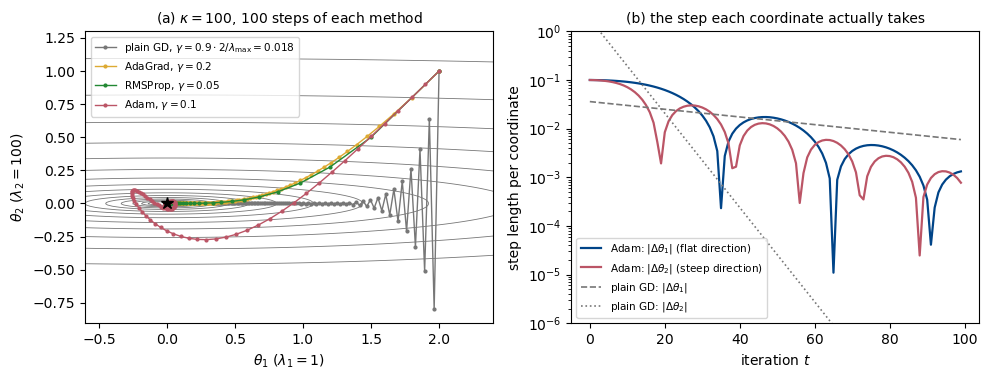

In [23]:
fig_adaptive_steps("week38_adaptive_steps.png")
Image("week38_adaptive_steps.png", width=900)

**Rotate the bowl.** The adaptive methods rescale *coordinates*. A valley that
runs diagonally has its curvature in the off-diagonal entries of the Hessian,
which no diagonal rescaling sees. Same eigenvalues, same $\kappa$ — and plain
gradient descent and momentum, whose behaviour Eq. (4.19) ties to the
eigenvalues alone, do not notice the rotation at all.

In [24]:
c, s = np.cos(np.pi / 4), np.sin(np.pi / 4)
Q = np.array([[c, -s], [s, c]])
print("the same bowl rotated by 45 degrees, iterations to 1e-4:")
for method, gamma in (("plain", 0.018), ("momentum", 0.018), ("adagrad", 0.2), ("rmsprop", 0.05), ("adam", 0.1)):
    aligned = optimise(grad_bowl, theta0, method, gamma, num_iters=5000)
    rotated = optimise(rotated_bowl_grad, Q @ theta0, method, gamma, num_iters=5000)
    print(f"  {method:8s}: axis-aligned {iterations_to(aligned, np.zeros(2), 1e-4)}, rotated {iterations_to(rotated, np.zeros(2), 1e-4)}")

the same bowl rotated by 45 degrees, iterations to 1e-4:
  plain   : axis-aligned 546, rotated 546
  momentum: axis-aligned 162, rotated 162
  adagrad : axis-aligned 297, rotated None
  rmsprop : axis-aligned 52, rotated None
  adam    : axis-aligned 151, rotated 635


  adagrad : axis-aligned 297, rotated None
  rmsprop : axis-aligned 52, rotated None


  adam    : axis-aligned 151, rotated 635


### Last week's unsolved problem: the Runge function at degree 10

The columns $x, x^2, \dots, x^{10}$ of a polynomial design matrix are strongly
correlated, so this valley is *not* axis-aligned: $\kappa = 2 \times 10^6$ at
degree 10, and in week 37 nothing converged. We plot the excess cost
$C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$ for the
five methods at degree 6 (where everything except RMSProp does converge) and at
degree 10.

In [25]:
def runge_data(n=100, degree=6, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()


RUNGE_RUNS = (('plain', None, '#777777', 'plain GD'), ('momentum', None, '#004488', 'momentum, $\\beta=0.9$'), ('adagrad', 0.5, '#DDAA33', 'AdaGrad, $\\gamma=0.5$'), ('rmsprop', 0.01, '#228833', 'RMSProp, $\\gamma=0.01$'), ('adam', 0.05, '#BB5566', 'Adam, $\\gamma=0.05$'))

def runge_comparison(degree=10, num_iters=30000):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = runge_data(degree=degree)
    theta_cf = closed_form(X, y)
    c_min = cost(theta_cf, X, y)
    eigs = hessian_eigs(X)
    gamma_gd = 0.9 * 2.0 / eigs.max()
    grad = lambda th: gradient(th, X, y)
    out = {}
    for method, gamma, _, _ in RUNGE_RUNS:
        g = gamma_gd if gamma is None else gamma
        path = optimise(grad, np.zeros(degree), method, g, num_iters=num_iters)
        out[method] = np.array([cost(th, X, y) - c_min for th in path])
    return out, eigs, gamma_gd


def fig_runge_optimisers(filename="week38_runge_optimisers.pdf"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    for ax, degree, num_iters in zip(axes, (6, 10), (20000, 30000)):
        excess, eigs, gamma_gd = runge_comparison(degree=degree, num_iters=num_iters)
        for method, gamma, col, lab in RUNGE_RUNS:
            ax.loglog(np.arange(1, len(excess[method]) + 1), np.maximum(excess[method], 1e-16), color=col, lw=1.4, label=lab)
        ax.set_xlabel("iteration $k$ (one full gradient each)")
        ax.set_title(rf"degree {degree}: $\kappa={eigs.max()/eigs.min():.1e}$, "
                     rf"plain/momentum at $\gamma=0.9\cdot2/\lambda_{{\max}}={gamma_gd:.2f}$", fontsize=9.5)
    axes[0].set_ylabel(r"$C(\boldsymbol{\theta}_k)-C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$")
    axes[0].set_ylim(1e-12, 10); axes[1].set_ylim(1e-4, 10)
    axes[0].legend(fontsize=8, loc="lower left")
    fig.tight_layout(); fig.savefig(filename, bbox_inches="tight"); plt.close(fig)


Runge degree 6: lambda_max = 5.995, lambda_min = 3.24e-03, kappa = 1.85e+03, gamma for plain/momentum = 0.300
  plain   : excess cost after 30000 iterations 0.0e+00; first below 1e-2 / 1e-4 / 1e-8: 253 / 2617 / 7346
  momentum: excess cost after 30000 iterations 0.0e+00; first below 1e-2 / 1e-4 / 1e-8: 36 / 246 / 670
  adagrad : excess cost after 30000 iterations 0.0e+00; first below 1e-2 / 1e-4 / 1e-8: 424 / 4333 / 12156
  rmsprop : excess cost after 30000 iterations 4.5e-04; first below 1e-2 / 1e-4 / 1e-8: 233 / None / None
  adam    : excess cost after 30000 iterations 4.7e-10; first below 1e-2 / 1e-4 / 1e-8: 127 / 574 / 1062
Runge degree 10: lambda_max = 9.973, lambda_min = 5.02e-06, kappa = 1.99e+06, gamma for plain/momentum = 0.180
  plain   : excess cost after 30000 iterations 3.8e-03; first below 1e-2 / 1e-4 / 1e-8: 2793 / None / None
  momentum: excess cost after 30000 iterations 2.2e-03; first below 1e-2 / 1e-4 / 1e-8: 287 / None / None
  adagrad : excess cost after 30000 ite

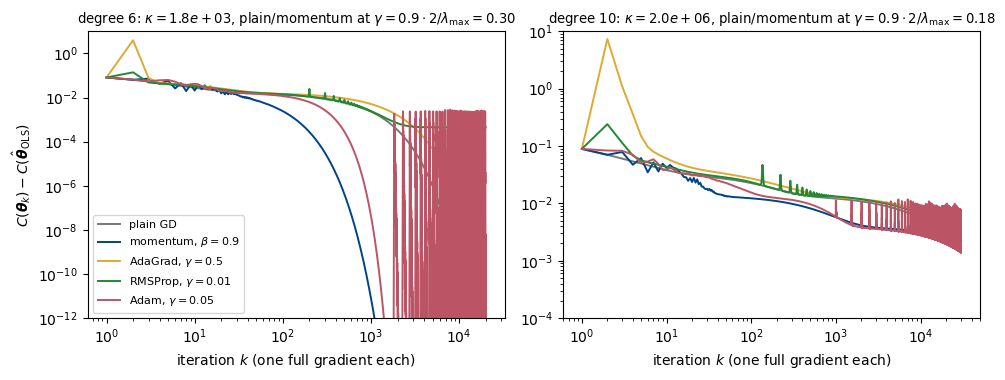

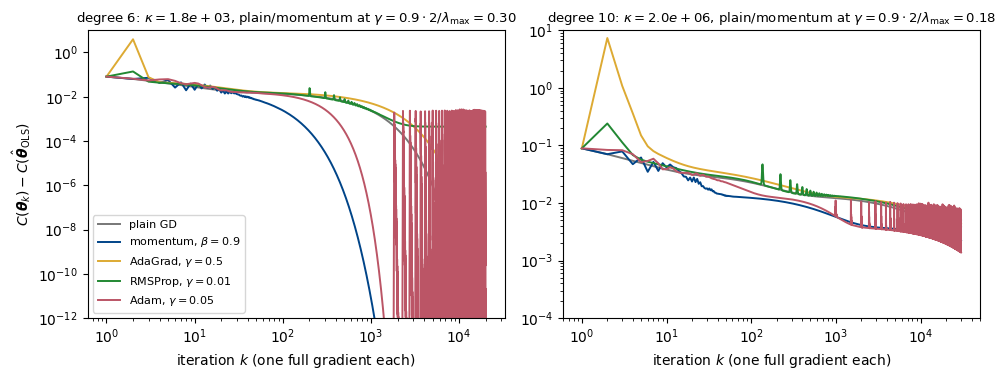

In [26]:
for degree in (6, 10):
    excess, eigs, gamma_gd = runge_comparison(degree=degree)
    print(f"Runge degree {degree}: lambda_max = {eigs.max():.3f}, lambda_min = {eigs.min():.2e}, "
          f"kappa = {eigs.max() / eigs.min():.2e}, gamma for plain/momentum = {gamma_gd:.3f}")
    for method, gamma, _, _ in RUNGE_RUNS:
        e = excess[method]
        first = {tol: (int(np.argmax(e < tol)) if (e < tol).any() else None) for tol in (1e-2, 1e-4, 1e-8)}
        print(f"  {method:8s}: excess cost after {len(e) - 1} iterations {max(e[-1], 0):.1e}; first below 1e-2 / 1e-4 / 1e-8: "
              f"{first[1e-2]} / {first[1e-4]} / {first[1e-8]}")
fig_runge_optimisers("week38_runge_optimisers.png")
Image("week38_runge_optimisers.png", width=900)

Two honest lessons. At degree 6, momentum ($670$ iterations to $10^{-8}$)
and Adam ($1062$) beat plain descent ($7346$) by an order of magnitude, AdaGrad
is slower than plain descent because its step sizes only ever shrink, and
RMSProp at a constant $\gamma$ never settles — near the minimum its step is
$\approx \gamma\,\mathrm{sign}(g)$, so it needs a decaying $\gamma$ (AdaGrad has
one built in; Adam's $\hat{\boldsymbol{m}}$ averages the sign changes away).
At degree 10, Adam reaches an excess cost of $10^{-2}$ in $462$ iterations
against $2793$ for plain descent, and then *everything* stalls between
$10^{-3}$ and $5 \times 10^{-3}$: no first-order method today resolves the
flat, non-axis-aligned directions of a $\kappa = 2 \times 10^6$ problem. What
does: one Newton step with the JAX Hessian (week 37, Case 2), or Ridge with
$\lambda = 10^{-3}$, which brings $\kappa$ to $5000$ — Tuesday, Case 1.

In [27]:
X10, y10 = runge_data(degree=10)
n10 = len(y10)
theta_cf = closed_form(X10, y10)
H10 = (2.0 / n10) * X10.T @ X10
theta_newton = np.zeros(10) - np.linalg.solve(H10, gradient(np.zeros(10), X10, y10))
print(f"one Newton step from zero: ||theta - closed form|| = {np.linalg.norm(theta_newton - theta_cf):.1e}")
for lam in (1e-3,):
    theta_r = closed_form(X10, y10, lam)
    eigs = hessian_eigs(X10, lam)
    for method, gamma in (("momentum", 0.9 * 2 / eigs.max()), ("adam", 0.05)):
        path = optimise(lambda th: gradient(th, X10, y10, lam), np.zeros(10), method, gamma, num_iters=30000)
        e = np.array([cost(th, X10, y10, lam) - cost(theta_r, X10, y10, lam) for th in path[::10]])
        k = int(np.argmax(e < 1e-8)) * 10 if (e < 1e-8).any() else None
        print(f"Ridge lambda = {lam} (kappa = {eigs.max() / eigs.min():.0f}): {method:8s} reaches excess cost 1e-8 after {k} iterations")

one Newton step from zero: ||theta - closed form|| = 5.9e-10
Ridge lambda = 0.001 (kappa = 4975): momentum reaches excess cost 1e-8 after 1330 iterations
Ridge lambda = 0.001 (kappa = 4975): adam     reaches excess cost 1e-8 after 1210 iterations


Ridge lambda = 0.001 (kappa = 4975): momentum reaches excess cost 1e-8 after 1330 iterations


Ridge lambda = 0.001 (kappa = 4975): adam     reaches excess cost 1e-8 after 1210 iterations


## Part 4: stochastic gradient descent (Section 4.7)

The cost is a sum over data points, Eq. (4.32), so its gradient is too. A
*minibatch* $B_k$ of $M$ points gives the estimate of Eq. (4.33),

$$
\nabla C(\boldsymbol{\theta}) \approx \frac{n}{M}\sum_{i \in B_k} \nabla c_i(\boldsymbol{x}_i, \boldsymbol{\theta}),
$$

(the factor $n/M$ keeps the scale of the full gradient; with the $1/n$ in our
cost this is simply the gradient of the cost evaluated on the minibatch), and
the update of Eq. (4.34) uses it in place of the full gradient. One pass through
all $n/M$ minibatches is an *epoch*. The estimate is unbiased, and by the
central limit theorem (Section 2.5) its noise falls as $1/\sqrt{M}$.

In [28]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches (Section 4.7)."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]


def step_length(t, t0, t1):
    """The learning-rate schedule of Eq. (4.40)."""
    return t0 / (t + t1)


def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None, **kw):
    """Minibatch stochastic gradient descent, Eq. (4.34), with any optimiser of optimiser_step.
    schedule=(t0, t1) replaces the constant gamma by Eq. (4.40).  Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype=float)
    state, t, history = {}, 0, [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)            # Eq. (4.33): the minibatch gradient
            g_t = gamma if schedule is None else step_length(t, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, g_t, **kw)
        history.append(theta.copy())
    return np.array(history)


In [29]:
X, y = exercise_data(degree=2)
n = len(y)
theta_cf = closed_form(X, y)
theta = np.array([0.0, 3.0])
g_full = gradient(theta, X, y)
rng = np.random.default_rng(2026)
print("full gradient at theta = (0, 3):", g_full)
for M in (1, 5, 25, 100):
    gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
    print(f"M = {M:3d}: mean of the minibatch gradients {np.round(gs.mean(axis=0), 3)}, "
          f"spread (mean std over the two components) {np.std(gs, axis=0).mean():.3f}")

full gradient at theta = (0, 3): [ 1.4783 -5.4542]
M =   1: mean of the minibatch gradients [ 1.478 -5.454], spread (mean std over the two components) 8.477
M =   5: mean of the minibatch gradients [ 1.478 -5.454], spread (mean std over the two components) 3.697
M =  25: mean of the minibatch gradients [ 1.478 -5.454], spread (mean std over the two components) 1.544
M = 100: mean of the minibatch gradients [ 1.478 -5.454], spread (mean std over the two components) 0.000


Centred on the full gradient, with a spread that halves when $M$ is
quadrupled. Now the descent itself: full-batch gradient descent at
$\gamma^* = 0.5$ (this problem has $\kappa = 1.27$ and converges in 11
iterations), SGD with $M = 5$ at two constant learning rates, and SGD with the
schedule $\gamma_t = t_0/(t + t_1)$ of Eq. (4.40), all plotted against the
number of single-point gradient evaluations, i.e. the computational cost.

In [30]:
for kwargs in (dict(batch_size=n, gamma=0.5, n_epochs=12), dict(batch_size=5, gamma=0.1), dict(batch_size=5, gamma=0.02),
               dict(batch_size=5, schedule=(1.0, 10.0)), dict(batch_size=20, gamma=0.1), dict(batch_size=1, gamma=0.1),
               dict(batch_size=5, gamma=0.05, method="adam")):
    kwargs = dict(n_epochs=100, **kwargs) if "n_epochs" not in kwargs else kwargs
    hist = sgd(X, y, **kwargs)
    d = np.linalg.norm(hist - theta_cf, axis=1)
    print(f"{str(kwargs):70s}: distance after 1 / 10 / last epochs {d[1]:.1e} / {d[min(10, len(d) - 1)]:.1e} / {d[-1]:.1e}")

{'batch_size': 100, 'gamma': 0.5, 'n_epochs': 12}                     : distance after 1 / 10 / last epochs 7.1e-01 / 3.2e-09 / 4.5e-11
{'n_epochs': 100, 'batch_size': 5, 'gamma': 0.1}                      : distance after 1 / 10 / last epochs 8.7e-02 / 6.5e-02 / 4.8e-02
{'n_epochs': 100, 'batch_size': 5, 'gamma': 0.02}                     : distance after 1 / 10 / last epochs 2.7e+00 / 1.2e-03 / 7.0e-03
{'n_epochs': 100, 'batch_size': 5, 'schedule': (1.0, 10.0)}           : distance after 1 / 10 / last epochs 7.2e-01 / 2.2e-02 / 4.7e-04
{'n_epochs': 100, 'batch_size': 20, 'gamma': 0.1}                     : distance after 1 / 10 / last epochs 2.1e+00 / 5.6e-03 / 9.0e-03
{'n_epochs': 100, 'batch_size': 1, 'gamma': 0.1}                      : distance after 1 / 10 / last epochs 2.0e-01 / 3.3e-01 / 5.3e-02
{'n_epochs': 100, 'batch_size': 5, 'gamma': 0.05, 'method': 'adam'}   : distance after 1 / 10 / last epochs 5.1e+00 / 5.0e-01 / 1.1e-02


In [31]:
def fig_sgd(filename="week38_sgd.pdf"):
    X, y = exercise_data(degree=2)
    n = len(y)
    theta_cf = closed_form(X, y)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    # (a) the cloud of minibatch gradients at one point
    ax = axes[0]
    theta = np.array([0.0, 3.0])
    g_full = gradient(theta, X, y)
    rng = np.random.default_rng(2026)
    for M, col, lab in ((5, YELLOW, "$M=5$"), (25, BLUE, "$M=25$")):
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        ax.scatter(gs[:, 0], gs[:, 1], s=8, color=col, alpha=0.5, label=rf"{lab}: spread {np.std(gs, axis=0).mean():.2f}")
    ax.plot(*g_full, "k*", ms=12, label="full gradient, $M=n=100$")
    ax.set_xlabel(r"$\partial C/\partial\theta_1$"); ax.set_ylabel(r"$\partial C/\partial\theta_2$")
    ax.set_title(r"(a) minibatch gradients at $\boldsymbol{\theta}=(0,3)$: noise $\propto1/\sqrt{M}$", fontsize=10)
    ax.legend(fontsize=8); ax.set_aspect("equal")
    # (b) distance to the minimum against gradient evaluations
    ax = axes[1]
    n_epochs = 100
    evals = np.arange(n_epochs + 1) * n
    for kwargs, col, lab in (
            (dict(batch_size=n, gamma=0.5), GREY, r"full batch, $\gamma=0.5=\gamma^*$"),
            (dict(batch_size=5, gamma=0.1), BLUE, r"SGD, $M=5$, $\gamma=0.1$ constant"),
            (dict(batch_size=5, gamma=0.02), YELLOW, r"SGD, $M=5$, $\gamma=0.02$ constant"),
            (dict(batch_size=5, schedule=(1.0, 10.0)), RED, r"SGD, $M=5$, $\gamma_t=1/(t+10)$, Eq. (4.40)")):
        hist = sgd(X, y, n_epochs=n_epochs, **kwargs)
        ax.semilogy(evals, np.linalg.norm(hist - theta_cf, axis=1), color=col, lw=1.6, label=lab)
    ax.set_xlabel("single-point gradient evaluations ($=$ epochs $\\times\\,n$)")
    ax.set_ylabel(r"$\|\boldsymbol{\theta}-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
    ax.set_title("(b) degree 2, $n=100$: the same computation, four ways", fontsize=10)
    ax.set_ylim(1e-6, 10); ax.legend(fontsize=7.5, loc="upper right")
    fig.tight_layout(); fig.savefig(filename, bbox_inches="tight"); plt.close(fig)


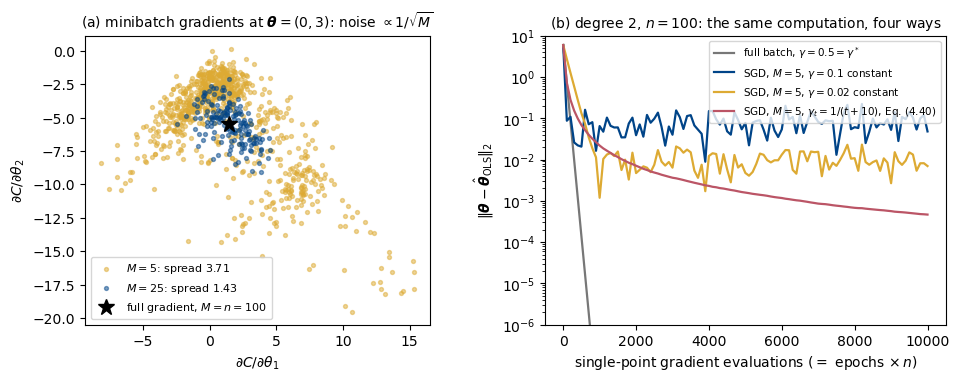

In [32]:
fig_sgd("week38_sgd.png")
Image("week38_sgd.png", width=900)

With a constant learning rate the iterate does not converge; it *equilibrates*
in a cloud around the minimum whose radius grows with $\gamma$ and shrinks with
$M$. The schedule of Eq. (4.40) satisfies the Robbins–Monro conditions
$\sum_t \gamma_t = \infty$, $\sum_t \gamma_t^2 < \infty$ and keeps descending.
On this benign problem full-batch descent wins per unit of computation after
the first few hundred evaluations; on a large data set the picture reverses,
because each SGD step costs $M/n$ of a full one. And in machine learning the
usual stopping rule is not about the gradient at all: monitor the validation
cost and stop when it rises (early stopping).

**Tuesday:** Case 1 puts the five optimisers into your own code on the Runge
problem (Project 1, part f); Case 2 does minibatches, batch sizes and
schedules (part h). The weekly exercises are due **Friday September 18 at
midnight**.